In [9]:
import uuid
import json
import numpy as np
import re
import matplotlib.pyplot as plt

In [2]:
# select keypoint data coco or vitpose
keypoint_selection = "coco"  # options: "coco" or "vitpose"

In [4]:
with open(f"{keypoint_selection}/curriculum_data/atomic_items.json", 'r') as f:
    atomic_items = json.load(f)
with open(f"{keypoint_selection}/curriculum_data/cot_items.json", 'r') as f:
    cot_items = json.load(f)
with open(f"{keypoint_selection}/curriculum_data/direct_items.json", 'r') as f:
    direct_items = json.load(f)

### Cot_data multitask

In [5]:
## create 400 (200*2) multitask data of direct labeling + CoT
reasoning_data = []
for i in range(200):
    direct_item = direct_items[i]

    reasoning_data.append(direct_item)

    ## cot data
    cot_item = cot_items[i]

    reasoning_data.append(cot_item)

len(reasoning_data)

400

In [6]:
# generate random IDs of length 32
ids = [str(uuid.uuid4()) for _ in range(len(atomic_items) + len(reasoning_data))]
ids[:3]

['9730c127-d87e-4177-b4cc-b33c245b3617',
 'c27c22c9-eae5-4e6b-99d3-0de021262390',
 'cc791817-f8dd-4d7e-a143-bc1035323f13']

In [7]:
# replace the IDs in the pose18k data and cot data with the generated IDs
atomic_ids = ids[:len(atomic_items)]
reasoning_ids = ids[len(atomic_items):]

for i in range(len(atomic_items)):
    atomic_items[i]['id'] = atomic_ids[i]
for i in range(len(reasoning_data)):
    reasoning_data[i]['id'] = reasoning_ids[i]

print(atomic_items[0])
print(reasoning_data[0])

{'id': '9730c127-d87e-4177-b4cc-b33c245b3617', 'image': '000000575933.jpg', 'conversations': [{'from': 'human', 'value': "<image>\nEstimate this person's pose."}, {'from': 'gpt', 'value': '<POSE_START><SHOULDER_L><X_101><Y_104><SHOULDER_R><X_64><Y_102><HIP_L><X_108><Y_211><HIP_R><X_71><Y_214><ORIENT_START><YAW_3><TORSO_W_2><ORIENT_END><POSE_END>'}]}
{'id': 'c4697bbb-387d-48a5-ab44-6632b7154e1e', 'image': '000000280760.jpg', 'conversations': [{'from': 'human', 'value': "<image>\nA person and a chair are shown in the image. Which side of the person is the chair on from the person's perspective?"}, {'from': 'gpt', 'value': 'left'}]}


In [8]:
len(atomic_items), len(reasoning_data)

(14000, 400)

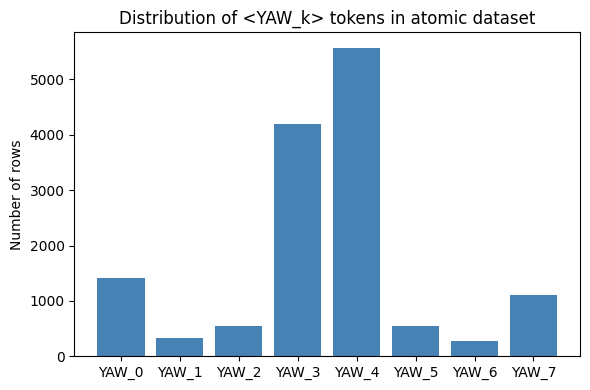

In [10]:
rows = atomic_items
yaw_pat = re.compile(r"<YAW_(\d)>")
counts  = [0]*8                     # bins 0 … 7

for ex in rows:
    m = yaw_pat.search(ex["conversations"][1]["value"])
    if m:
        counts[int(m.group(1))] += 1

# ------- 3.  Plot -----------------------------------------------------
plt.figure(figsize=(6,4))
plt.bar(range(8), counts, color="steelblue")
plt.xticks(range(8), [f"YAW_{k}" for k in range(8)])
plt.ylabel("Number of rows")
plt.title("Distribution of <YAW_k> tokens in atomic dataset")
plt.tight_layout()
plt.show()

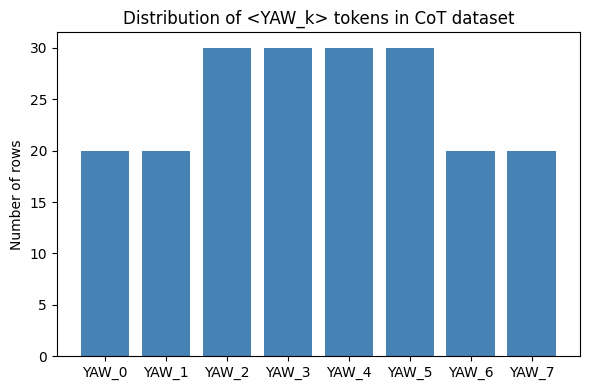

In [11]:
import re
import matplotlib.pyplot as plt
from pathlib import Path

rows = cot_items
yaw_pat = re.compile(r"<YAW_(\d)>")
counts  = [0]*8                     # bins 0 … 7

for ex in rows:
    m = yaw_pat.search(ex["conversations"][1]["value"])
    if m:
        counts[int(m.group(1))] += 1

# ------- 3.  Plot -----------------------------------------------------
plt.figure(figsize=(6,4))
plt.bar(range(8), counts, color="steelblue")
plt.xticks(range(8), [f"YAW_{k}" for k in range(8)])
plt.ylabel("Number of rows")
plt.title("Distribution of <YAW_k> tokens in CoT dataset")
plt.tight_layout()
plt.show()

In [12]:
aligned_cot    = [row for row in cot_items
                  if any(f"<YAW_{k}>" in row["conversations"][1]["value"]
                         for k in (0,1,6,7))]   # aligned bins
unaligned_cot  = [row for row in cot_items
                  if row not in aligned_cot]     # bins 2,3,4,5
print(aligned_cot[:3], unaligned_cot[:3])
print(len(aligned_cot), len(unaligned_cot))

[{'id': '0b13ab90-c952-4282-8967-30f98ea2f973', 'image': '000000280760.jpg', 'conversations': [{'from': 'human', 'value': "<image>\nA person and a chair are shown in the image. Which side of the person is the chair on from the person's perspective?\nTo answer this question, let's think through it step by step, and we know the image is 336 x 336. First, what is the chair's position relative to the person from the viewer's frame?\nSecond, what is the person's pose in token form?\nThird, from the pose, what is the person's orientation bin and do they face toward or away from the viewer?\nFourth, mentally rotate the viewer's frame to align with the person's orientation, what side of the person did the chair end up on?\n"}, {'from': 'gpt', 'value': "The chair is left of the person from the viewer's frame. The person's pose is <POSE_START><SHOULDER_L><X_224><Y_179><SHOULDER_R><X_249><Y_175><HIP_L><X_213><Y_215><HIP_R><X_229><Y_222><ORIENT_START><YAW_0><TORSO_W_2><ORIENT_END><POSE_END>. Since

In [13]:
# shuffle atomic_items and reasoning_data
import random
random.shuffle(atomic_items)
random.shuffle(reasoning_data)

In [14]:
## make a single training file having the data for all 10 epochs sequentially

import random
epochs = 10
total_length = len(atomic_items)
random.seed(0)
percents = [1, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2 , 0.1]
total_cot_size = 0
annealing_data =[]
for epoch in range(epochs):
    percent = percents[epoch]
    epoch_depth_data = random.sample(atomic_items, int(total_length * percent) )
    cot_length = total_length - int(total_length * percent)
    repeat = cot_length//len(reasoning_data)
    epoch_cot_data = reasoning_data * repeat
    total_epoch_data = epoch_depth_data + epoch_cot_data
    annealing_data += total_epoch_data
    total_cot_size+= len(epoch_cot_data)
    
    
    
print(len(annealing_data), total_cot_size)

139000 62000


In [ ]:
def write_json(data, filename):
    with open(filename, 'w') as f:
        json.dump(data, f, indent=2)
write_json(annealing_data, f"../data/train_perspective_annealing_data_{keypoint_selection}.json")

## text token annealing data

In [18]:
cot_text_items_path = f"{keypoint_selection}/curriculum_data/cot_items_text.json"
atomic_text_items_path = f"{keypoint_selection}/curriculum_data/atomic_items_text.json"

with open(cot_text_items_path, 'r') as f:
    cot_text_items = json.load(f)
with open(atomic_text_items_path, 'r') as f:
    atomic_text_data = json.load(f)
print(len(cot_text_items), len(atomic_text_data))

200 14000


In [19]:
## create 400 (200*2) multitask data of direct labeling + CoT
reasoning_text_data = []
for i in range(200):
    direct_item = direct_items[i]
    
    reasoning_text_data.append(direct_item)
    
    ## cot data
    cot_item = cot_text_items[i]

    reasoning_text_data.append(cot_item)

len(reasoning_text_data)

400

In [20]:
# replace the IDs in the atomic data and reasoning data with the generated IDs
for i in range(len(atomic_text_data)):
    atomic_text_data[i]['id'] = atomic_ids[i]
for i in range(len(reasoning_text_data)):
    reasoning_text_data[i]['id'] = reasoning_ids[i]

print(atomic_text_data[0])
print(reasoning_text_data[0])

{'id': '9730c127-d87e-4177-b4cc-b33c245b3617', 'image': '575933.jpg', 'conversations': [{'from': 'human', 'value': '<image>\nReturn the pose-estimation tokens for the person in the picture.'}, {'from': 'gpt', 'value': '101 104 64 102 108 211 71 214 3 2'}]}
{'id': 'c4697bbb-387d-48a5-ab44-6632b7154e1e', 'image': '000000280760.jpg', 'conversations': [{'from': 'human', 'value': "<image>\nA person and a chair are shown in the image. Which side of the person is the chair on from the person's perspective?"}, {'from': 'gpt', 'value': 'left'}]}


In [21]:
import random
random.shuffle(atomic_text_data)
random.shuffle(reasoning_text_data)

In [ ]:
## make a single training file having the data for all 10 epochs sequentially

epochs = 10
total_length = len(atomic_text_data)
random.seed(0)
percents = [1, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2 , 0.1]
total_cot_size = 0
annealing_data =[]
for epoch in range(epochs):
    percent = percents[epoch]
    epoch_depth_data = random.sample(atomic_text_data, int(total_length * percent) )
    cot_length = total_length - int(total_length * percent)
    repeat = cot_length//len(reasoning_text_data)
    epoch_cot_data = reasoning_text_data * repeat
    total_epoch_data = epoch_depth_data + epoch_cot_data
    annealing_data += total_epoch_data
    total_cot_size+= len(epoch_cot_data)
    
    
    
print(len(annealing_data), total_cot_size)

179000 80000


In [ ]:
def write_json(data, filename):
    with open(filename, 'w') as f:
        json.dump(data, f, indent=2)
write_json(annealing_data, f"../data/train_text_annealing_data_{keypoint_selection}.json")